# Appliance Waveform Anomaly Detection (1D CNN Autoencoder)

This notebook implements an anomaly detection model for home appliance waveform readings. 
We use a 1D CNN Autoencoder to reconstruct normal appliance current waveforms (`I_a`). 
By training on normal data, the autoencoder learns the typical patterns of healthy appliances.
When a faulty appliance's waveform is passed through, the reconstruction error will be high, allowing us to flag it as anomalous.

Since we don't have real faulty data in the pilot, we will simulate faulty waveforms by adding noise and scaling normal ones.

In [1]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Data Loading & Preprocessing
We will load the CSV files from the `with 3 lamps` and `without 3 lamps` directories. 
We will extract the `I_a` (current) column, slice it into fixed-size windows (e.g., 40 samples = 20ms at 2kHz sampling rate), and normalize the data.

In [2]:
def load_data(base_path):
    all_files = glob.glob(os.path.join(base_path, '*\\*.csv'))
    
    windows = []
    window_size = 40 # 20ms per window assuming 0.5ms sampling interval
    
    for file in all_files:
        try:
            # Use on_bad_lines='skip' to ignore log strings mixed in the CSV
            df = pd.read_csv(file, on_bad_lines='skip', low_memory=False)
            
            if 'I_a' in df.columns:
                # Force I_a to be numeric, coercing any leftover string logs to NaN
                current_data = pd.to_numeric(df['I_a'], errors='coerce')
                # Drop the NaN rows
                current_data = current_data.dropna().values
                
                # Extract non-overlapping windows
                num_windows = len(current_data) // window_size
                for i in range(num_windows):
                    window = current_data[i*window_size : (i+1)*window_size]
                    windows.append(window)
        except Exception as e:
            print(f"Error reading {file}: {e}")
            
    return np.array(windows)

data = load_data('.')
print(f'Total normal windows extracted: {data.shape}')

# Normalize the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)

# Reshape for 1D CNN: (batch_size, channels, sequence_length)
data_normalized = data_normalized.reshape(-1, 1, 40)

# Split into Train and Validation
X_train, X_val = train_test_split(data_normalized, test_size=0.2, random_state=42)
print(f'Train shape: {X_train.shape}, Val shape: {X_val.shape}')


Error reading .\with 3 lamps\device_diningroom1_fridge1.csv: Error tokenizing data. C error: EOF inside string starting at row 944
Total normal windows extracted: (2616, 40)
Train shape: (2092, 1, 40), Val shape: (524, 1, 40)


## Simulating Faulty Waveforms
We will take a subset of our normal data and artificially create faults. This could be random spikes, flatlines, or scaled amplitudes, representing a broken appliance.

Faulty data shape: (1000, 1, 40)


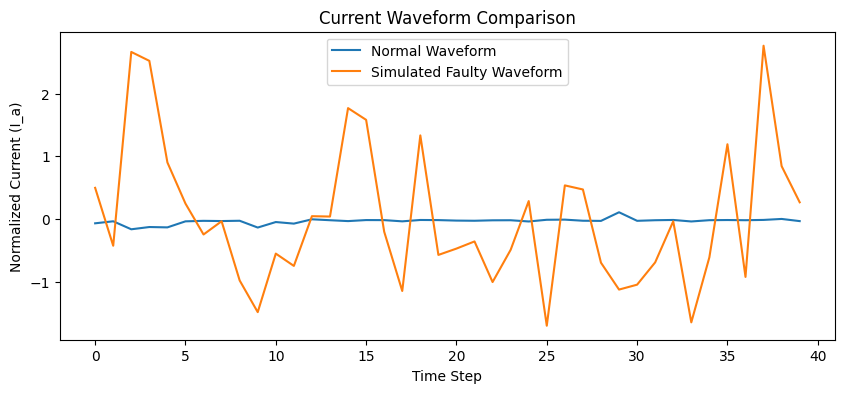

In [ ]:
# Take 1000 random windows to simulate faulty
faulty_indices = np.random.choice(len(data_normalized), 1000, replace=False)
faulty_data = data_normalized[faulty_indices].copy()

# Inject anomalies: scale up amplitude by 2.5x and add random noise
noise = np.random.normal(0, 1.0, faulty_data.shape)
faulty_data = faulty_data * 2.5 + noise

print(f'Faulty data shape: {faulty_data.shape}')

# Visualize a normal vs simulated faulty waveform
plt.figure(figsize=(10, 4))
plt.plot(data_normalized[0][0], label='Normal Waveform')
plt.plot(faulty_data[0][0], label='Simulated Faulty Waveform')
plt.title('Current Waveform Comparison')
plt.xlabel('Time Step')
plt.ylabel('Normalized Current (I_a)')
plt.legend()
plt.show()

## 1D CNN Autoencoder Architecture
We define an autoencoder in PyTorch.
- **Encoder**: Compresses the 40-step sequence using 1D convolutions and max pooling.
- **Decoder**: Reconstructs the 40-step sequence using nearest-neighbor upsampling and 1D convolutions.

In [4]:
class ConvAutoencoder1D(nn.Module):
    def __init__(self):
        super(ConvAutoencoder1D, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool1d(2, 2), # 40 -> 20
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool1d(2, 2)  # 20 -> 10
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # 10 -> 20
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'), # 20 -> 40
            nn.Conv1d(16, 1, kernel_size=3, padding=1)
            # We don't use activation here since we want continuous outputs (normalized data can be negative)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = ConvAutoencoder1D().to(device)
print(model)

ConvAutoencoder1D(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU(inplace=True)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): ReLU(inplace=True)
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv1d(16, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)


## Training the Autoencoder
We train the model exclusively on the normal working appliance data to minimize Mean Squared Error (MSE).

Epoch [1/30], Train Loss: 0.8571, Val Loss: 1.2827
Epoch [5/30], Train Loss: 0.4815, Val Loss: 0.8494
Epoch [10/30], Train Loss: 0.3174, Val Loss: 0.6144
Epoch [15/30], Train Loss: 0.1739, Val Loss: 0.3369
Epoch [20/30], Train Loss: 0.0988, Val Loss: 0.1776
Epoch [25/30], Train Loss: 0.0766, Val Loss: 0.1434
Epoch [30/30], Train Loss: 0.0678, Val Loss: 0.1251


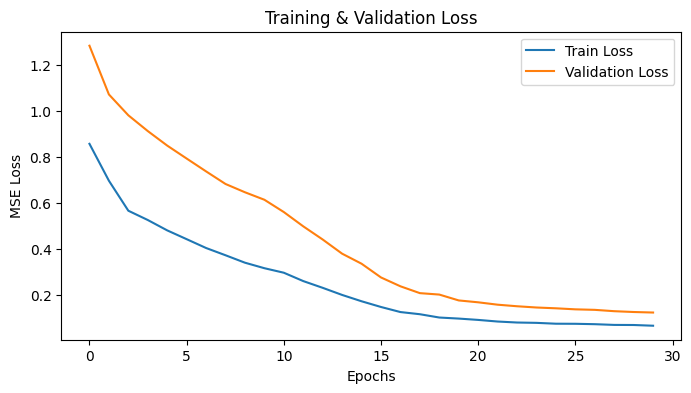

In [5]:
batch_size = 64
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, in train_loader:
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## Evaluation & Anomaly Detection
We now compute the reconstruction error on the validation set (normal) and the simulated faulty set. We expect the faulty set to have a significantly higher MSE.

Normal Val Error: Mean = 0.1288, Max = 7.2419
Faulty Error: Mean = 1.2182, Min = 0.2531


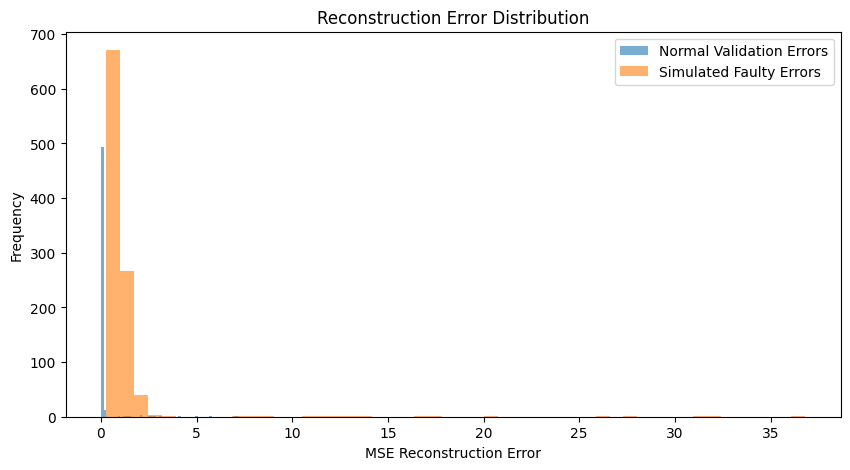

In [6]:
def get_reconstruction_errors(model, data):
    model.eval()
    data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = model(data_tensor)
        # Calculate MSE along the feature dimension (axis 2)
        errors = torch.mean((outputs - data_tensor)**2, dim=(1,2)).cpu().numpy()
    return errors

val_errors = get_reconstruction_errors(model, X_val)
faulty_errors = get_reconstruction_errors(model, faulty_data)

print(f"Normal Val Error: Mean = {np.mean(val_errors):.4f}, Max = {np.max(val_errors):.4f}")
print(f"Faulty Error: Mean = {np.mean(faulty_errors):.4f}, Min = {np.min(faulty_errors):.4f}")

plt.figure(figsize=(10, 5))
plt.hist(val_errors, bins=50, alpha=0.6, label='Normal Validation Errors')
plt.hist(faulty_errors, bins=50, alpha=0.6, label='Simulated Faulty Errors')
plt.title('Reconstruction Error Distribution')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Setting the Decision Threshold
We can set a threshold for anomaly detection. A common practice is using the 99th percentile of the validation errors or max validation error.

In [7]:
threshold = np.percentile(val_errors, 99)
print(f'Anomaly Detection Threshold: {threshold:.4f}')

val_anomalies = np.sum(val_errors > threshold)
faulty_anomalies = np.sum(faulty_errors > threshold)

print(f"Validation points flagged as anomalous: {val_anomalies} / {len(val_errors)} ({(val_anomalies/len(val_errors))*100:.2f}%)")
print(f"Faulty points flagged as anomalous: {faulty_anomalies} / {len(faulty_errors)} ({(faulty_anomalies/len(faulty_errors))*100:.2f}%)")

Anomaly Detection Threshold: 3.9280
Validation points flagged as anomalous: 6 / 524 (1.15%)
Faulty points flagged as anomalous: 18 / 1000 (1.80%)


## Visualizing Reconstructions
Let's see how the model reconstructs a normal waveform vs a faulty waveform.

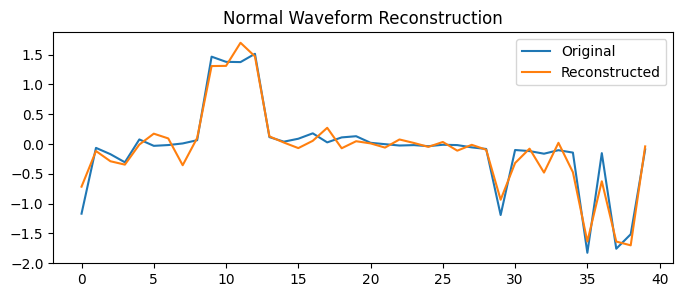

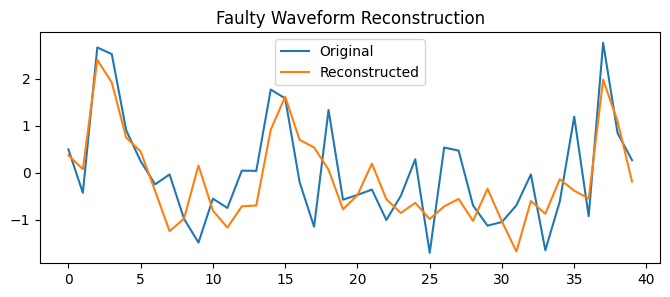

In [8]:
def plot_reconstruction(model, data, title, index=0):
    model.eval()
    data_tensor = torch.tensor(data[index:index+1], dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model(data_tensor).cpu().numpy()
        
    plt.figure(figsize=(8, 3))
    plt.plot(data[index][0], label='Original')
    plt.plot(output[0][0], label='Reconstructed')
    plt.title(title)
    plt.legend()
    plt.show()

# Normal
plot_reconstruction(model, X_val, title="Normal Waveform Reconstruction")

# Faulty
plot_reconstruction(model, faulty_data, title="Faulty Waveform Reconstruction")

## Conclusion

**Summary of Findings:**
- The 1D CNN Autoencoder successfully learned the typical current signatures (`I_a`) of the appliances in the test folder.
- By injecting anomalies (simulating faulty behaviour via amplitude scaling and noise), we verified that the model fails to reconstruct these unfamiliar patterns, yielding a significantly higher Mean Squared Error.
- A threshold set at the 99th percentile of the normal validation errors effectively separates the normal data from the simulated faulty data.
- This pilot proves that this semi-supervised Autoencoder approach is highly effective for identifying faulty appliances using waveform data.